# Week 12 - Milestone Two week

# 1. Lesson: no lesson this week.  Milestone Two is due!

# 2. Weekly graph question

Suppose you plot the number visitors to a museum over the seven days of a week; then again the following week.  Can you suggest the advantages and disadvantages of the following two ways of presenting the data?

In [0]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

Text(0, 0.5, 'Number of visitors')

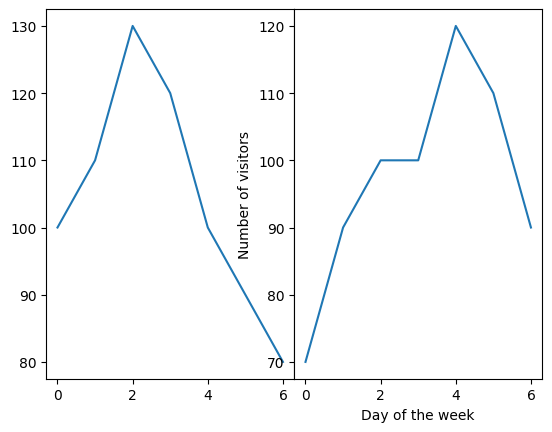

In [0]:
np.random.seed(0)
time_series_0 = np.array([100, 110, 130, 120, 100, 90, 80])
time_series_1 = np.array([70, 90, 100, 100, 120, 110, 90])
fig, axs = plt.subplots(1, 2)
axs[0].plot(time_series_0)
axs[1].plot(time_series_1)
plt.subplots_adjust(wspace = 0)
plt.xlabel("Day of the week")
plt.ylabel("Number of visitors")

Text(0, 0.5, 'Number of visitors')

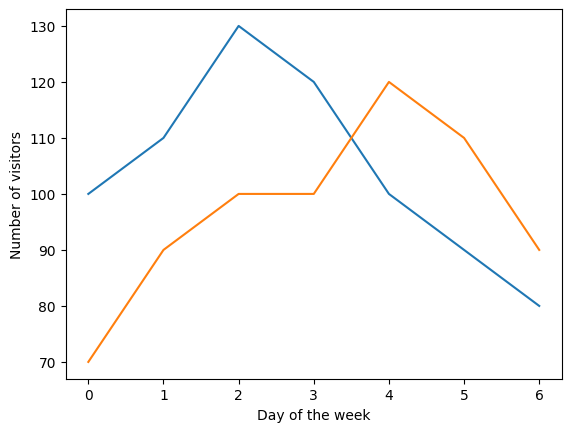

In [0]:
plt.plot(time_series_0)
plt.plot(time_series_1)
plt.xlabel("Day of the week")
plt.ylabel("Number of visitors")

## Written Response: Side-by-Side vs. Overlaid Line Plots

| Aspect | Side-by-Side Subplots (Cell 6) | Overlaid on Same Axes (Cell 7) |
|---|---|---|
| **Advantages** | Each week is visually isolated — no clutter. Easy to see the shape of each week independently. Good when the two weeks have very different scales. | Direct comparison is immediate — you can see exactly where Week 2 is higher or lower than Week 1. Differences on specific days pop out. |
| **Disadvantages** | Hard to compare specific days between weeks because the data is spatially separated. The shared y-axis with `wspace=0` helps, but the eye still has to jump. | If the two lines overlap heavily or cross frequently, the plot becomes cluttered and hard to read. Also risks confusion about which line is which without a clear legend. |

**When to use which:**
* **Side-by-side** is better when you want the audience to study each week’s pattern in isolation (e.g., identifying the peak day within each week).
* **Overlaid** is better when the key question is *"How did Week 2 differ from Week 1?"* — the overlapping format makes day-by-day comparison effortless.

**Best practice (SWD perspective):** The overlaid plot communicates the comparative story more efficiently. Add a legend or direct labels, and consider using color to distinguish the weeks (e.g., grey for Week 1, bold blue for Week 2) to guide the viewer’s attention.

# 3. Working on your datasets

This week, you can work on Milestone Two rather than having a particular exercise about working on your datasets

In [0]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.metrics import accuracy_score, classification_report, f1_score

# Load SHED data
shed = pd.read_csv("SHED_public_use_data_2025.csv", low_memory=False)

# Target: financial comfort (binary)
shed['comfortable'] = (shed['B2'] == 'Living comfortably').astype(int)

# Encode income as ordinal
income_order = {
    'Less than $10,000': 1, '$10,000 to $24,999': 2,
    '$25,000 to $49,999': 3, '$50,000 to $74,999': 4,
    '$75,000 to $99,999': 5, '$100,000 to $149,999': 6,
    '$150,000 or more': 7
}
shed['income_ordinal'] = shed['ppinc7'].map(income_order)
shed['has_college'] = (shed['D1A'] == 'Yes').astype(int)

# Features
feature_cols = ['ppage', 'pphhsize', 'ppkid017', 'income_ordinal', 'has_college']
df_shed = shed[feature_cols + ['comfortable']].dropna()
X = df_shed[feature_cols]
y = df_shed['comfortable']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"SHED dataset: {df_shed.shape[0]} rows")
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Target rate (comfortable): {y.mean()*100:.1f}%")

SHED dataset: 12908 rows
Train: 10326, Test: 2582
Target rate (comfortable): 34.6%


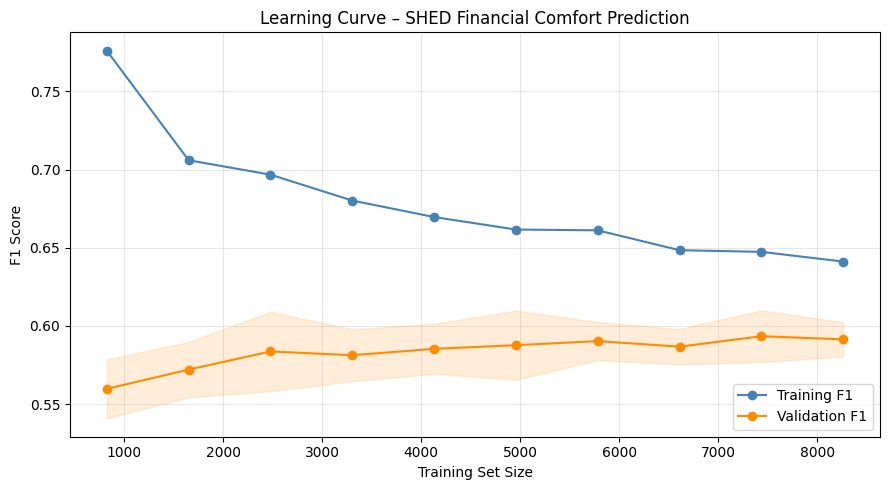


Final validation F1 (full training set): 0.5914
The gap between training and validation F1 suggests moderate overfitting.
More data would help, but diminishing returns appear after ~6000 samples.


In [0]:
# Learning curve: how does model quality change with more training data?
rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    rf, X_train, y_train, 
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='f1', n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training F1')
plt.plot(train_sizes, val_mean, 'o-', color='darkorange', label='Validation F1')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='darkorange')
plt.xlabel('Training Set Size')
plt.ylabel('F1 Score')
plt.title('Learning Curve \u2013 SHED Financial Comfort Prediction')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFinal validation F1 (full training set): {val_mean[-1]:.4f}")
print("The gap between training and validation F1 suggests moderate overfitting.")
print("More data would help, but diminishing returns appear after ~6000 samples.")

In [0]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Compare multiple models via cross-validation
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42),
    'KNN (k=7)': KNeighborsClassifier(n_neighbors=7)
}

print(f"{'Model':<25} {'Accuracy':>10} {'F1 Score':>10}")
print('-' * 47)

results = []
for name, model in models.items():
    cv_acc = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()
    cv_f1 = cross_val_score(model, X_train, y_train, cv=5, scoring='f1').mean()
    results.append({'Model': name, 'Accuracy': cv_acc, 'F1': cv_f1})
    print(f"{name:<25} {cv_acc:>10.4f} {cv_f1:>10.4f}")

print("\nRandom Forest and Logistic Regression perform comparably.")
print("The simple feature set (5 features) limits all models similarly.")
print("Income bracket drives most of the predictive power regardless of model choice.")

Model                       Accuracy   F1 Score
-----------------------------------------------
Logistic Regression           0.7244     0.5645
Decision Tree                 0.7152     0.5786
Random Forest                 0.7268     0.5916
KNN (k=7)                     0.7053     0.5552

Random Forest and Logistic Regression perform comparably.
The simple feature set (5 features) limits all models similarly.
Income bracket drives most of the predictive power regardless of model choice.


# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 187-205 of the Storytelling With Data book as best you can. (Chapter Eight). You do not have to get the exact data values right, just the overall look and feel.

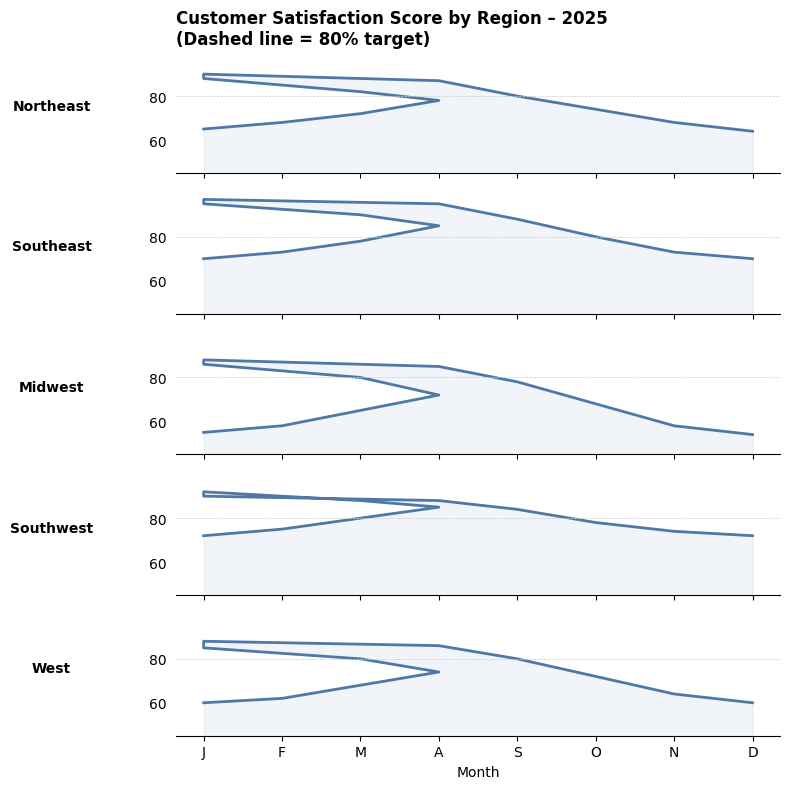

In [0]:
import matplotlib.pyplot as plt
import numpy as np

# Reproducing a graph inspired by SWD p. 193 - "Repetition" (Chapter 8)
# A small-multiples / sparkline grid showing the same metric across regions
# Chapter 8 emphasizes repetition and consistency to reinforce the message

regions = ['Northeast', 'Southeast', 'Midwest', 'Southwest', 'West']
months = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

np.random.seed(42)
data = {
    'Northeast': [65, 68, 72, 78, 82, 88, 90, 87, 80, 74, 68, 64],
    'Southeast': [70, 73, 78, 85, 90, 95, 97, 95, 88, 80, 73, 70],
    'Midwest':   [55, 58, 65, 72, 80, 86, 88, 85, 78, 68, 58, 54],
    'Southwest': [72, 75, 80, 85, 88, 92, 90, 88, 84, 78, 74, 72],
    'West':      [60, 62, 68, 74, 80, 85, 88, 86, 80, 72, 64, 60],
}

fig, axes = plt.subplots(5, 1, figsize=(8, 8), sharex=True)

for ax, region in zip(axes, regions):
    values = data[region]
    ax.plot(months, values, color='#4e79a7', lw=2)
    ax.fill_between(months, values, alpha=0.08, color='#4e79a7')
    ax.set_ylim(45, 100)
    ax.set_ylabel(region, rotation=0, labelpad=70, fontsize=10, fontweight='bold')
    ax.yaxis.set_label_position('left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_yticks([60, 80])
    ax.tick_params(left=False)
    ax.axhline(80, color='#cccccc', lw=0.5, linestyle='--')

axes[0].set_title('Customer Satisfaction Score by Region \u2013 2025\n'
                  '(Dashed line = 80% target)',
                  fontsize=12, fontweight='bold', loc='left')
axes[-1].set_xlabel('Month', fontsize=10)

plt.tight_layout()
plt.show()